# Ingestion & Structural Analysis

**Import libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from autogluon.tabular import TabularPredictor
import warnings
warnings.filterwarnings("ignore")

# Set up global visualization configurations        `   `
sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (12, 6)

print("=== Cell 1: Libraries Imported Successfully ===")

c:\Users\MuthakanaDineshKumar\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


=== Cell 1: Libraries Imported Successfully ===


**Load datasets**

In [2]:
print("=== Cell 2: Loading JED Airport Ramp Safety Data ===")
train_df = pd.read_csv("ramp_safety_train.csv")
val_df = pd.read_csv("ramp_safety_validation.csv")
test_df = pd.read_csv("ramp_safety_test.csv")

print(f"Training Set Shape:   {train_df.shape}")
print(f"Validation Set Shape: {val_df.shape}")
print(f"Testing Set Shape:    {test_df.shape}")

=== Cell 2: Loading JED Airport Ramp Safety Data ===
Training Set Shape:   (28000, 15)
Validation Set Shape: (6000, 15)
Testing Set Shape:    (6000, 15)


**Check for null values and duplicate values**

In [3]:
print("=== Cell 3: Missing Values Audit ===")
print(train_df.isnull().sum())

print("\n=== Duplicate Rows Audit (by shift_id) ===")
duplicates = train_df.duplicated(subset=['shift_id']).sum()
print(f"Total duplicate shifts: {duplicates}")

=== Cell 3: Missing Values Audit ===
shift_id                       0
timestamp                      0
weather_condition              0
visibility_meters              0
temperature_celsius            0
wind_speed_kmph                0
worker_fatigue_hours           0
overtime_workers_count         0
equipment_fault_count          0
communication_failure_count    0
active_staff_count             0
aircraft_on_ramp_count         0
day_traffic_profile            0
safety_risk_score              0
risk_category                  0
dtype: int64

=== Duplicate Rows Audit (by shift_id) ===
Total duplicate shifts: 0


In [4]:
print(" Descriptive Statistics & Most Repeated Values")

# 1. Get base summary stats (min, max, mean)
num_cols = train_df.select_dtypes(include=[np.number]).columns
summary_df = train_df[num_cols].describe().T[['min', 'max', 'mean']]

# 2. Calculate the mode (most frequent value) and its count for each column
modes = []
mode_counts = []

for col in num_cols:
    mode_val = train_df[col].mode()[0]
    mode_cnt = (train_df[col] == mode_val).sum()
    modes.append(mode_val)
    mode_counts.append(mode_cnt)

# 3. Combine into a single analytical table
summary_df['most_repeated_value'] = modes
summary_df['repeat_count'] = mode_counts

print(summary_df)

 Descriptive Statistics & Most Repeated Values
                               min     max         mean  most_repeated_value  \
visibility_meters            300.0  9999.0  6770.003429               7000.0   
temperature_celsius           20.0    46.5    30.888029                 38.0   
wind_speed_kmph                0.0    55.0    18.285286                 20.0   
worker_fatigue_hours           0.0     9.5     4.306957                  6.0   
overtime_workers_count         0.0    12.0     4.521357                  2.0   
equipment_fault_count          0.0     8.0     1.974214                  0.0   
communication_failure_count    0.0     4.0     1.295857                  1.0   
active_staff_count            60.0   229.0   126.495393                110.0   
aircraft_on_ramp_count         3.0    25.0    12.128000                 20.0   
safety_risk_score              0.2     0.9     0.511349                  0.9   

                             repeat_count  
visibility_meters           

In [5]:
print("Cell 5: Category Frequency Analysis")

cat_cols = ['weather_condition', 'day_traffic_profile', 'risk_category']

for col in cat_cols:
    print(f"\n--- Distribution Profile for Feature: '{col}' ---")
    counts = train_df[col].value_counts()
    percentages = train_df[col].value_counts(normalize=True) * 100
    
    # Combine counts and percentages into a clear display
    freq_table = pd.DataFrame({'Total Records': counts, 'Percentage (%)': percentages})
    print(freq_table)
    
    print(f"-> Most repeated option (Max):  '{counts.index[0]}' (Repeated {counts.iloc[0]} times)")
    print(f"-> Least repeated option (Min): '{counts.index[-1]}' (Repeated {counts.iloc[-1]} times)")

Cell 5: Category Frequency Analysis

--- Distribution Profile for Feature: 'weather_condition' ---
                   Total Records  Percentage (%)
weather_condition                               
CLEAR                      19858       70.921429
DUST_HAZE                   4550       16.250000
EXTREME_HEAT                1814        6.478571
SANDSTORM                   1778        6.350000
-> Most repeated option (Max):  'CLEAR' (Repeated 19858 times)
-> Least repeated option (Min): 'SANDSTORM' (Repeated 1778 times)

--- Distribution Profile for Feature: 'day_traffic_profile' ---
                     Total Records  Percentage (%)
day_traffic_profile                               
WEEKDAY_CALM                 19988       71.385714
WEEKEND_RUSH                  8012       28.614286
-> Most repeated option (Max):  'WEEKDAY_CALM' (Repeated 19988 times)
-> Least repeated option (Min): 'WEEKEND_RUSH' (Repeated 8012 times)

--- Distribution Profile for Feature: 'risk_category' ---
           

# Exploratory Data Analysis

Visualizing Simplified Operational Visibility Brackets


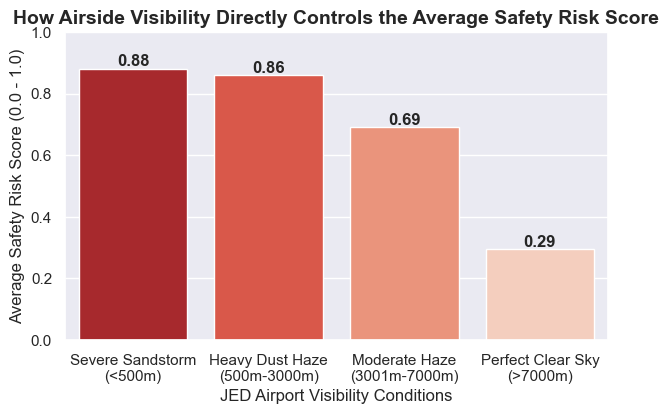

In [6]:
print("Visualizing Simplified Operational Visibility Brackets")

# 1. Create a temporary copy to avoid modifying our main training dataset
binned_df = train_df.copy()

# 2. Group the continuous visibility meters into 4 distinct airport brackets
visibility_bins = [0, 500, 3000, 7000, 10000]
visibility_labels = [
    'Severe Sandstorm\n(<500m)', 
    'Heavy Dust Haze\n(500m-3000m)', 
    'Moderate Haze\n(3001m-7000m)', 
    'Perfect Clear Sky\n(>7000m)'
]

binned_df['visibility_bracket'] = pd.cut(
    binned_df['visibility_meters'], 
    bins=visibility_bins, 
    labels=visibility_labels
)

# 3. Create a clean bar chart showing the exact mean risk score for each bracket
plt.figure(figsize=(7, 4))
ax = sns.barplot(
    data=binned_df, 
    x='visibility_bracket', 
    y='safety_risk_score', 
    palette='Reds_r', 
    errorbar=None
)

# 4. Display the exact average decimals on top of each bar automatically
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', fontsize=12, weight='bold')

plt.title('How Airside Visibility Directly Controls the Average Safety Risk Score', fontsize=14, weight='bold')
plt.xlabel('JED Airport Visibility Conditions', fontsize=12)
plt.ylabel('Average Safety Risk Score (0.0 - 1.0)', fontsize=12)
plt.ylim(0, 1.0) # Keeps the chart mapped exactly to our absolute risk boundaries
plt.show()

 Visualizing Operational Worker Fatigue Brackets


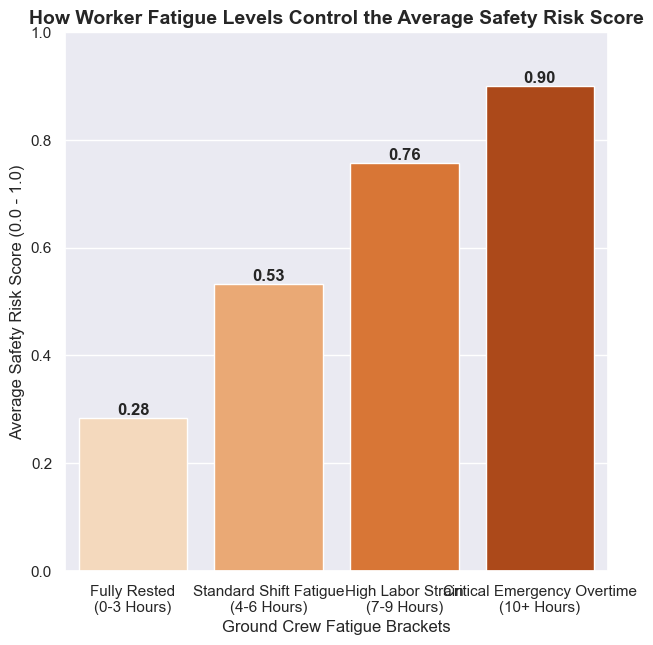

In [7]:
print(" Visualizing Operational Worker Fatigue Brackets")

# 1. Create a clean copy to segment fatigue hours
fatigue_df = train_df.copy()

# 2. Divide fatigue hours into realistic operational shift brackets
fatigue_bins = [-1, 3, 6, 9, 13]
fatigue_labels = [
    'Fully Rested\n(0-3 Hours)', 
    'Standard Shift Fatigue\n(4-6 Hours)', 
    'High Labor Strain\n(7-9 Hours)', 
    'Critical Emergency Overtime\n(10+ Hours)'
]

fatigue_df['fatigue_bracket'] = pd.cut(
    fatigue_df['worker_fatigue_hours'], 
    bins=fatigue_bins, 
    labels=fatigue_labels
)

# 3. Plot the average risk score for each fatigue bracket
plt.figure(figsize=(7, 7))
ax = sns.barplot(
    data=fatigue_df, 
    x='fatigue_bracket', 
    y='safety_risk_score', 
    palette='Oranges', 
    errorbar=None
)

# 4. Add the precise decimal numbers on top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', fontsize=12, weight='bold')

plt.title('How Worker Fatigue Levels Control the Average Safety Risk Score', fontsize=14, weight='bold')
plt.xlabel('Ground Crew Fatigue Brackets', fontsize=12)
plt.ylabel('Average Safety Risk Score (0.0 - 1.0)', fontsize=12)
plt.ylim(0, 1.0)
plt.show()

= Visualizing Adjusted Wind Speed Bracket


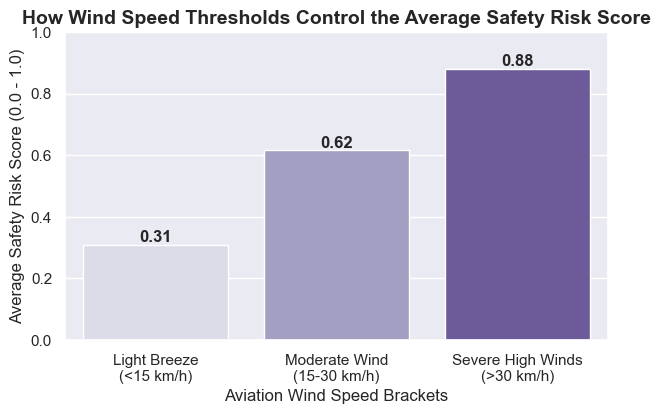

In [8]:
print("= Visualizing Adjusted Wind Speed Bracket")

wind_df = train_df.copy()

# New simplified bins matching the actual data distribution
# 0-15: Light, 15-30: Moderate, 30-60: High/Severe Storms
corrected_bins = [-1, 15, 30, 60]
corrected_labels = [
    'Light Breeze\n(<15 km/h)', 
    'Moderate Wind\n(15-30 km/h)', 
    'Severe High Winds\n(>30 km/h)'
]

wind_df['wind_bracket_fixed'] = pd.cut(
    wind_df['wind_speed_kmph'], 
    bins=corrected_bins, 
    labels=corrected_labels
)

# Plot the cleaned categories
plt.figure(figsize=(7, 4))
ax = sns.barplot(
    data=wind_df, 
    x='wind_bracket_fixed', 
    y='safety_risk_score', 
    palette='Purples', 
    errorbar=None
)

# Add clear decimal numbers on top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', fontsize=12, weight='bold')

plt.title('How Wind Speed Thresholds Control the Average Safety Risk Score', fontsize=14, weight='bold')
plt.xlabel('Aviation Wind Speed Brackets', fontsize=12)
plt.ylabel('Average Safety Risk Score (0.0 - 1.0)', fontsize=12)
plt.ylim(0, 1.0)
plt.show()

In [9]:
import seaborn as sns

Visualizing Weather Condition vs. Safety Risk Score


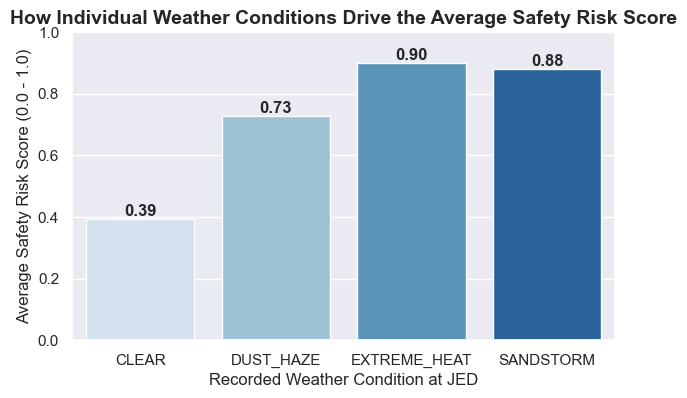

In [10]:
print("Visualizing Weather Condition vs. Safety Risk Score")

plt.figure(figsize=(7, 4))
ax = sns.barplot(
    data=train_df, 
    x='weather_condition', 
    y='safety_risk_score', 
    palette='Blues', 
    errorbar=None,
    order=['CLEAR', 'DUST_HAZE', 'EXTREME_HEAT', 'SANDSTORM']
)

# Add the exact average decimal numbers on top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', fontsize=12, weight='bold')

plt.title('How Individual Weather Conditions Drive the Average Safety Risk Score', fontsize=14, weight='bold')
plt.xlabel('Recorded Weather Condition at JED', fontsize=12)
plt.ylabel('Average Safety Risk Score (0.0 - 1.0)', fontsize=12)
plt.ylim(0, 1.0)
plt.show()

Visualizing Ramp Traffic Density vs. Safety Risk Score 


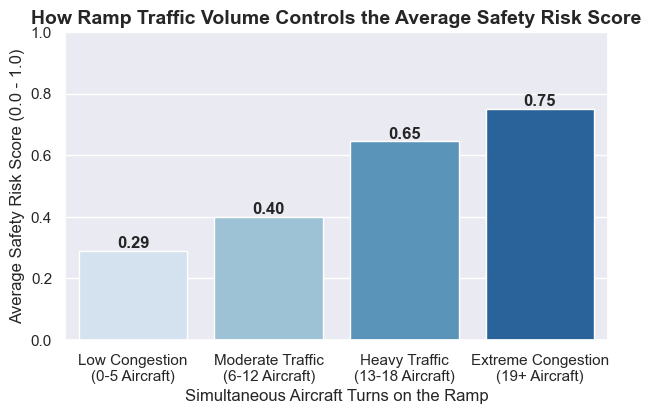

In [11]:
print("Visualizing Ramp Traffic Density vs. Safety Risk Score ")

congestion_df = train_df.copy()

# Break the continuous aircraft count into clear operational congestion brackets
congestion_bins = [0, 5, 12, 18, 26]
congestion_labels = [
    'Low Congestion\n(0-5 Aircraft)', 
    'Moderate Traffic\n(6-12 Aircraft)', 
    'Heavy Traffic\n(13-18 Aircraft)', 
    'Extreme Congestion\n(19+ Aircraft)'
]

congestion_df['congestion_bracket'] = pd.cut(
    congestion_df['aircraft_on_ramp_count'], 
    bins=congestion_bins, 
    labels=congestion_labels
)

# Plot the average risk score for each traffic tier
plt.figure(figsize=(7, 4))
ax = sns.barplot(
    data=congestion_df, 
    x='congestion_bracket', 
    y='safety_risk_score', 
    palette='Blues', 
    errorbar=None
)

# Add the exact average decimal numbers on top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', fontsize=12, weight='bold')

plt.title('How Ramp Traffic Volume Controls the Average Safety Risk Score', fontsize=14, weight='bold')
plt.xlabel('Simultaneous Aircraft Turns on the Ramp', fontsize=12)
plt.ylabel('Average Safety Risk Score (0.0 - 1.0)', fontsize=12)
plt.ylim(0, 1.0)
plt.show()

Visualizing Distribution of High-Risk Situations


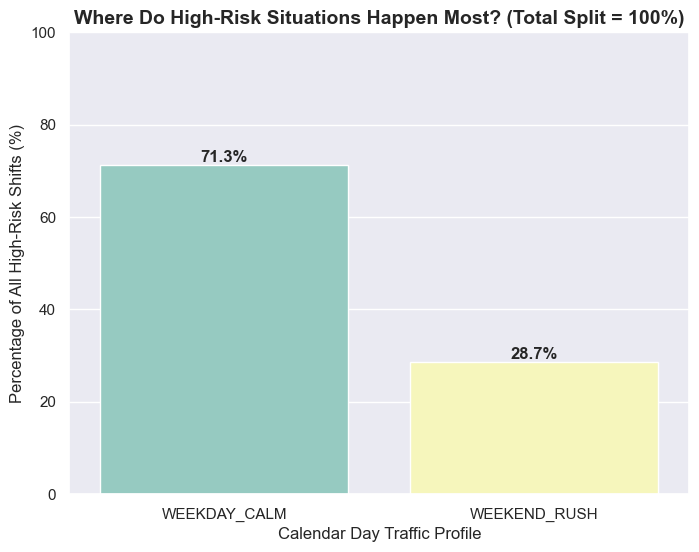

In [12]:
print("Visualizing Distribution of High-Risk Situations")

# 1. Filter the dataset to look ONLY at High Risk categories
high_risk_data = train_df[train_df['risk_category'] == 'HIGH_RISK']

# 2. Calculate the exact percentage breakdown across the calendar profiles
percentage_distribution = high_risk_data['day_traffic_profile'].value_counts(normalize=True) * 100

# Convert to a DataFrame for easy plotting
percentage_df = percentage_distribution.reset_index()
percentage_df.columns = ['day_traffic_profile', 'Percentage of High-Risk Shifts']

# 3. Plot the final percentage split
plt.figure(figsize=(8, 6))
ax = sns.barplot(
    data=percentage_df, 
    x='day_traffic_profile', 
    y='Percentage of High-Risk Shifts', 
    palette='Set3'
)

# Add the % labels clearly on top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', fontsize=12, weight='bold')

plt.title('Where Do High-Risk Situations Happen Most? (Total Split = 100%)', fontsize=14, weight='bold')
plt.xlabel('Calendar Day Traffic Profile', fontsize=12)
plt.ylabel('Percentage of All High-Risk Shifts (%)', fontsize=12)
plt.ylim(0, 100) # Force the scale to 100%
plt.show()

 Visualizing Total Weather Risk Contribution


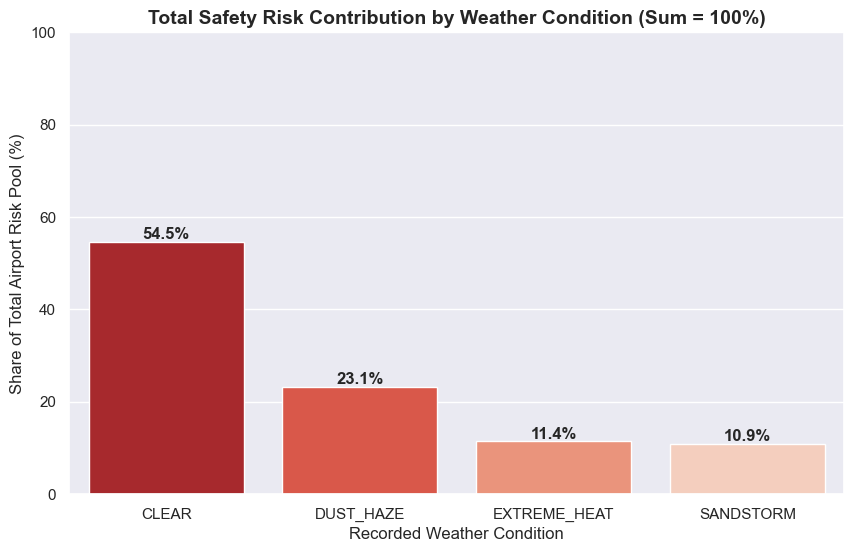

In [13]:
print(" Visualizing Total Weather Risk Contribution")

# 1. Calculate total risk pool for weather
total_weather_risk = train_df['safety_risk_score'].sum()

# 2. Group by weather and find percentage contribution
weather_contrib = (train_df.groupby('weather_condition')['safety_risk_score'].sum() / total_weather_risk) * 100
weather_contrib_df = weather_contrib.reset_index().columns = ['Weather Condition', 'Risk Contribution (%)']
weather_contrib_df = weather_contrib.reset_index()
weather_contrib_df.columns = ['Weather Condition', 'Risk Contribution (%)']

# 3. Plot the contribution chart
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=weather_contrib_df, 
    x='Weather Condition', 
    y='Risk Contribution (%)', 
    palette='Reds_r',
    order=['CLEAR', 'DUST_HAZE', 'EXTREME_HEAT', 'SANDSTORM']
)

# Add exact % labels on top
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', fontsize=12, weight='bold')

plt.title('Total Safety Risk Contribution by Weather Condition (Sum = 100%)', fontsize=14, weight='bold')
plt.xlabel('Recorded Weather Condition', fontsize=12)
plt.ylabel('Share of Total Airport Risk Pool (%)', fontsize=12)
plt.ylim(0, 100)
plt.show()

Visualizing Total Worker Fatigue Risk Contribution


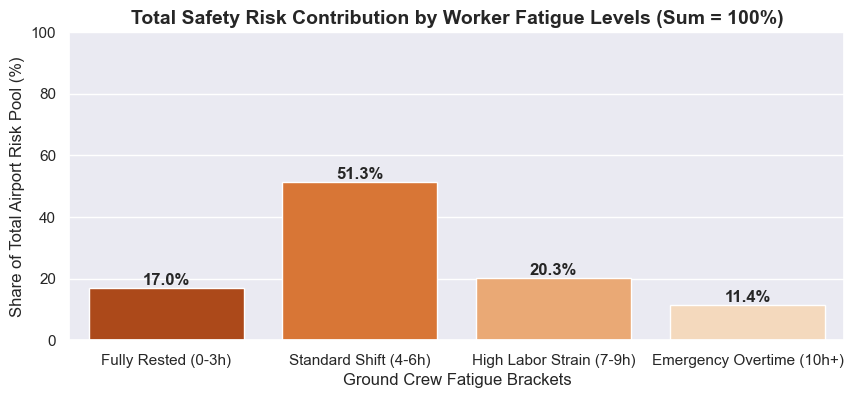

In [14]:
print("Visualizing Total Worker Fatigue Risk Contribution")

# 1. Group fatigue hours using our operational labels
fatigue_bins = [-1, 3, 6, 9, 13]
fatigue_labels = [
    'Fully Rested (0-3h)', 
    'Standard Shift (4-6h)', 
    'High Labor Strain (7-9h)', 
    'Emergency Overtime (10h+)'
]
train_df['fatigue_bracket'] = pd.cut(train_df['worker_fatigue_hours'], bins=fatigue_bins, labels=fatigue_labels)

# 2. Calculate percentage contribution to total risk pool
total_fatigue_risk = train_df['safety_risk_score'].sum()
fatigue_contrib = (train_df.groupby('fatigue_bracket', observed=False)['safety_risk_score'].sum() / total_fatigue_risk) * 100
fatigue_contrib_df = fatigue_contrib.reset_index()
fatigue_contrib_df.columns = ['Fatigue Bracket', 'Risk Contribution (%)']

# 3. Plot the contribution chart
plt.figure(figsize=(10,4))
ax = sns.barplot(
    data=fatigue_contrib_df, 
    x='Fatigue Bracket', 
    y='Risk Contribution (%)', 
    palette='Oranges_r'
)

# Add exact % labels on top
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', fontsize=12, weight='bold')

plt.title('Total Safety Risk Contribution by Worker Fatigue Levels (Sum = 100%)', fontsize=14, weight='bold')
plt.xlabel('Ground Crew Fatigue Brackets', fontsize=12)
plt.ylabel('Share of Total Airport Risk Pool (%)', fontsize=12)
plt.ylim(0, 100)
plt.show()

Visualizing Equipment Faults vs. Average Safety Risk Score


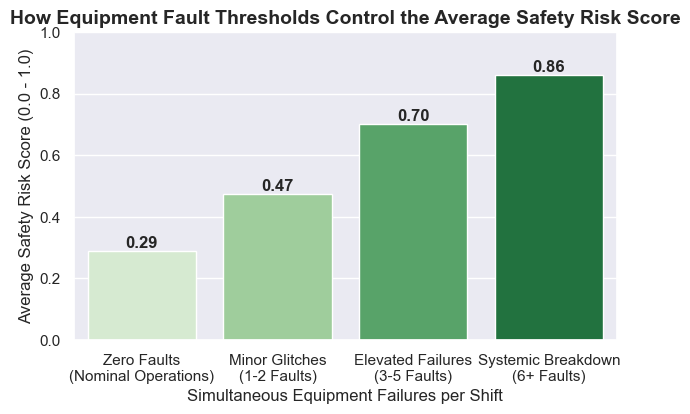

In [15]:
print("Visualizing Equipment Faults vs. Average Safety Risk Score")

# Create a clean copy to segment fault counts into clear operational states
fault_df = train_df.copy()

# Group raw fault numbers into distinct situational tiers
fault_bins = [-1, 0, 2, 5, 9]
fault_labels = [
    'Zero Faults\n(Nominal Operations)', 
    'Minor Glitches\n(1-2 Faults)', 
    'Elevated Failures\n(3-5 Faults)', 
    'Systemic Breakdown\n(6+ Faults)'
]

fault_df['fault_bracket'] = pd.cut(
    fault_df['equipment_fault_count'], 
    bins=fault_bins, 
    labels=fault_labels
)

# Plot the average risk score for each machinery failure bracket
plt.figure(figsize=(7,4))
ax = sns.barplot(
    data=fault_df, 
    x='fault_bracket', 
    y='safety_risk_score', 
    palette='Greens', 
    errorbar=None
)

# Add the exact average decimal numbers on top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', fontsize=12, weight='bold')

plt.title('How Equipment Fault Thresholds Control the Average Safety Risk Score', fontsize=14, weight='bold')
plt.xlabel('Simultaneous Equipment Failures per Shift', fontsize=12)
plt.ylabel('Average Safety Risk Score (0.0 - 1.0)', fontsize=12)
plt.ylim(0, 1.0)
plt.show()

Visualizing Communication Failures vs. Average Safety Risk Score


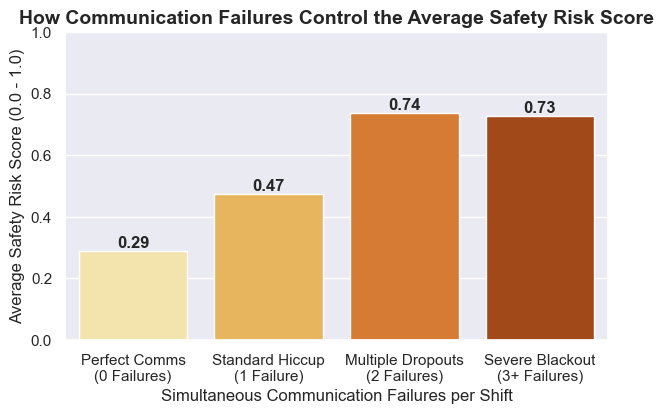

In [16]:
print("Visualizing Communication Failures vs. Average Safety Risk Score")

comm_df = train_df.copy()

# Group raw dropout counts into clear operational thresholds
comm_bins = [-1, 0, 1, 2, 5]
comm_labels = [
    'Perfect Comms\n(0 Failures)', 
    'Standard Hiccup\n(1 Failure)', 
    'Multiple Dropouts\n(2 Failures)', 
    'Severe Blackout\n(3+ Failures)'
]

comm_df['comm_bracket'] = pd.cut(
    comm_df['communication_failure_count'], 
    bins=comm_bins, 
    labels=comm_labels
)

# Plot the average risk score for each communication failure tier
plt.figure(figsize=(7,4))
ax = sns.barplot(
    data=comm_df, 
    x='comm_bracket', 
    y='safety_risk_score', 
    palette='YlOrBr', 
    errorbar=None
)

# Add the exact average numbers on top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', fontsize=12, weight='bold')

plt.title('How Communication Failures Control the Average Safety Risk Score', fontsize=14, weight='bold')
plt.xlabel('Simultaneous Communication Failures per Shift', fontsize=12)
plt.ylabel('Average Safety Risk Score (0.0 - 1.0)', fontsize=12)
plt.ylim(0, 1.0)
plt.show()

Visualizing Weather + Traffic Congestion via Grouped Bars


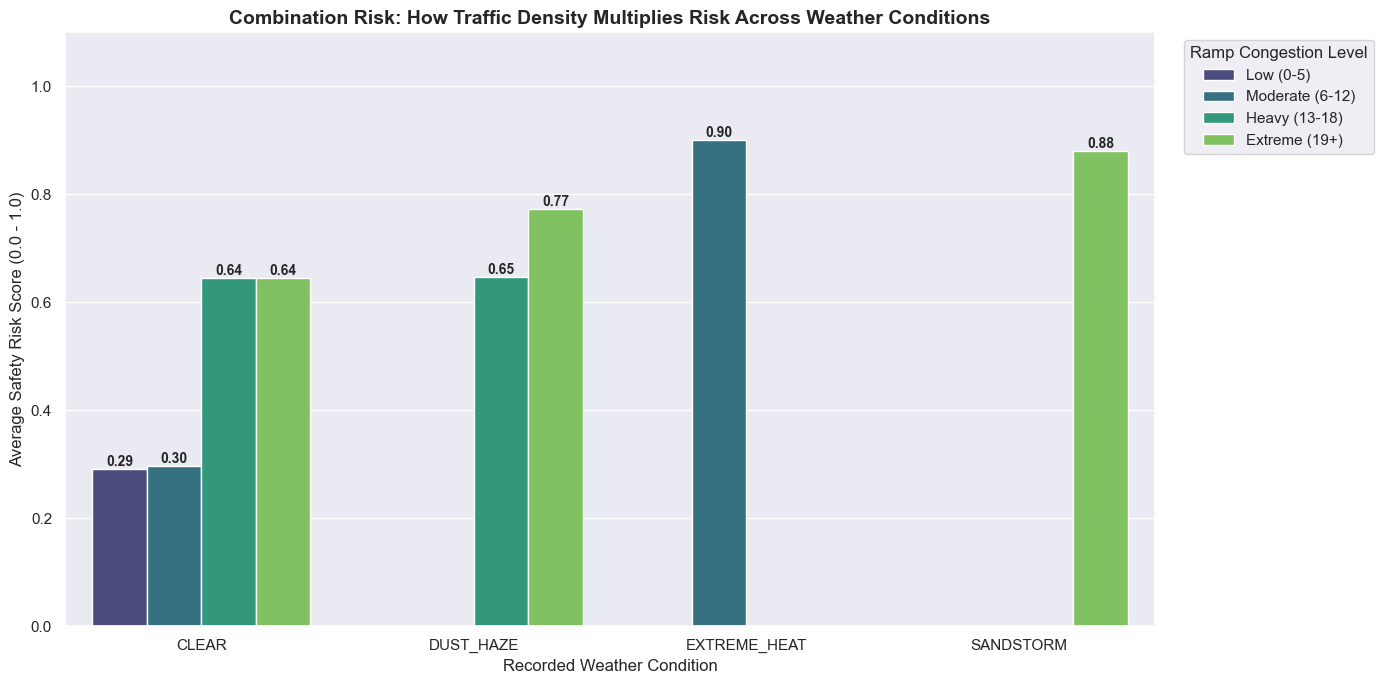

In [17]:
print("Visualizing Weather + Traffic Congestion via Grouped Bars")

# 1. Ensure the aircraft brackets are set up correctly
train_df['aircraft_bracket'] = pd.cut(
    train_df['aircraft_on_ramp_count'], 
    bins=[0, 5, 12, 18, 26], 
    labels=['Low (0-5)', 'Moderate (6-12)', 'Heavy (13-18)', 'Extreme (19+)']
)

# 2. Plot side-by-side grouped bars
plt.figure(figsize=(14, 7))
ax = sns.barplot(
    data=train_df, 
    x='weather_condition', 
    y='safety_risk_score', 
    hue='aircraft_bracket', 
    palette='viridis', 
    errorbar=None,
    order=['CLEAR', 'DUST_HAZE', 'EXTREME_HEAT', 'SANDSTORM']
)

# 3. Add exact average decimal labels on top of every bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', fontsize=10, weight='bold')

plt.title('Combination Risk: How Traffic Density Multiplies Risk Across Weather Conditions', fontsize=14, weight='bold')
plt.xlabel('Recorded Weather Condition', fontsize=12)
plt.ylabel('Average Safety Risk Score (0.0 - 1.0)', fontsize=12)
plt.ylim(0, 1.1)  # Leave a little room at the top for labels
plt.legend(title='Ramp Congestion Level', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

Visualizing Heat + Worker Fatigue Intersection


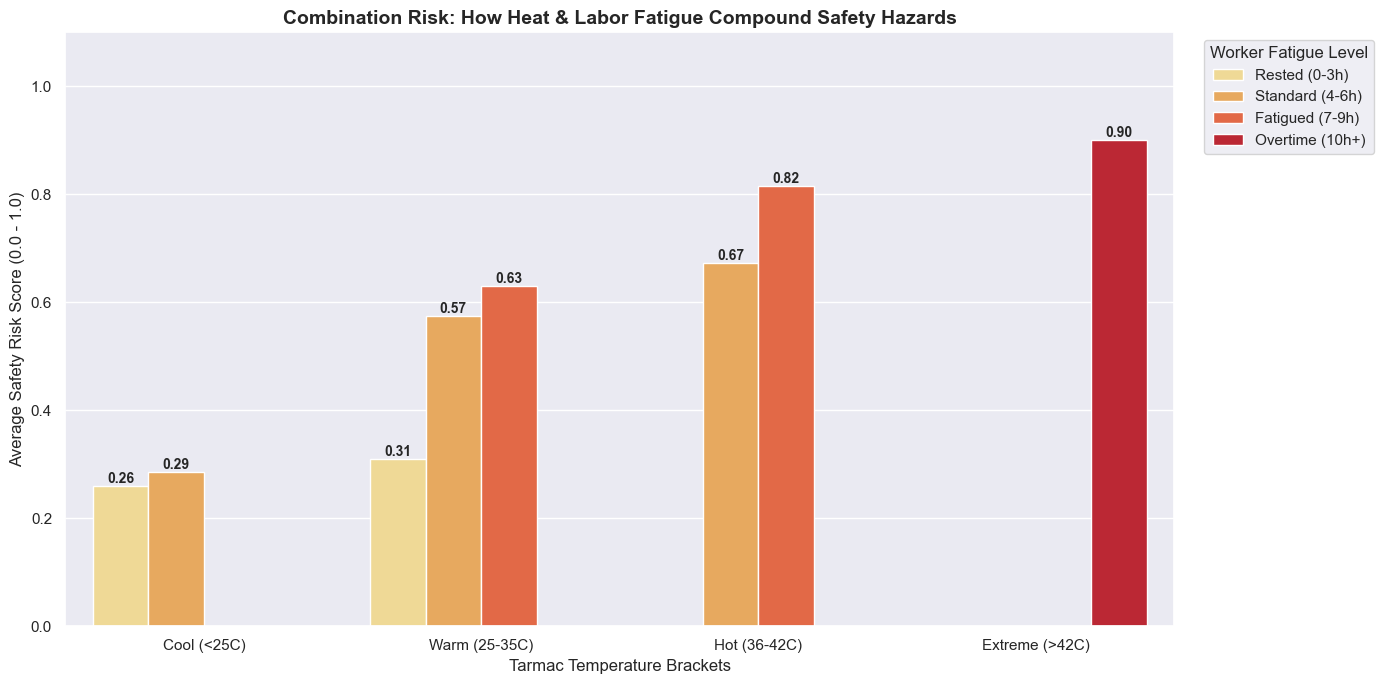

In [18]:
print("Visualizing Heat + Worker Fatigue Intersection")

# 1. Ensure the operational brackets for Temperature and Fatigue are set up
train_df['temp_bracket'] = pd.cut(
    train_df['temperature_celsius'], 
    bins=[15, 25, 35, 42, 50],
    labels=['Cool (<25C)', 'Warm (25-35C)', 'Hot (36-42C)', 'Extreme (>42C)']
)

train_df['fatigue_bracket'] = pd.cut(
    train_df['worker_fatigue_hours'], 
    bins=[-1, 3, 6, 9, 13],
    labels=['Rested (0-3h)', 'Standard (4-6h)', 'Fatigued (7-9h)', 'Overtime (10h+)']
)

# 2. Plot side-by-side grouped bars
plt.figure(figsize=(14, 7))
ax = sns.barplot(
    data=train_df, 
    x='temp_bracket', 
    y='safety_risk_score', 
    hue='fatigue_bracket', 
    palette='YlOrRd', 
    errorbar=None
)

# 3. Add exact average decimal labels on top of every bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', fontsize=10, weight='bold')

plt.title('Combination Risk: How Heat & Labor Fatigue Compound Safety Hazards', fontsize=14, weight='bold')
plt.xlabel('Tarmac Temperature Brackets', fontsize=12)
plt.ylabel('Average Safety Risk Score (0.0 - 1.0)', fontsize=12)
plt.ylim(0, 1.1)
plt.legend(title='Worker Fatigue Level', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

Visualizing Equipment Faults + Communication Failures


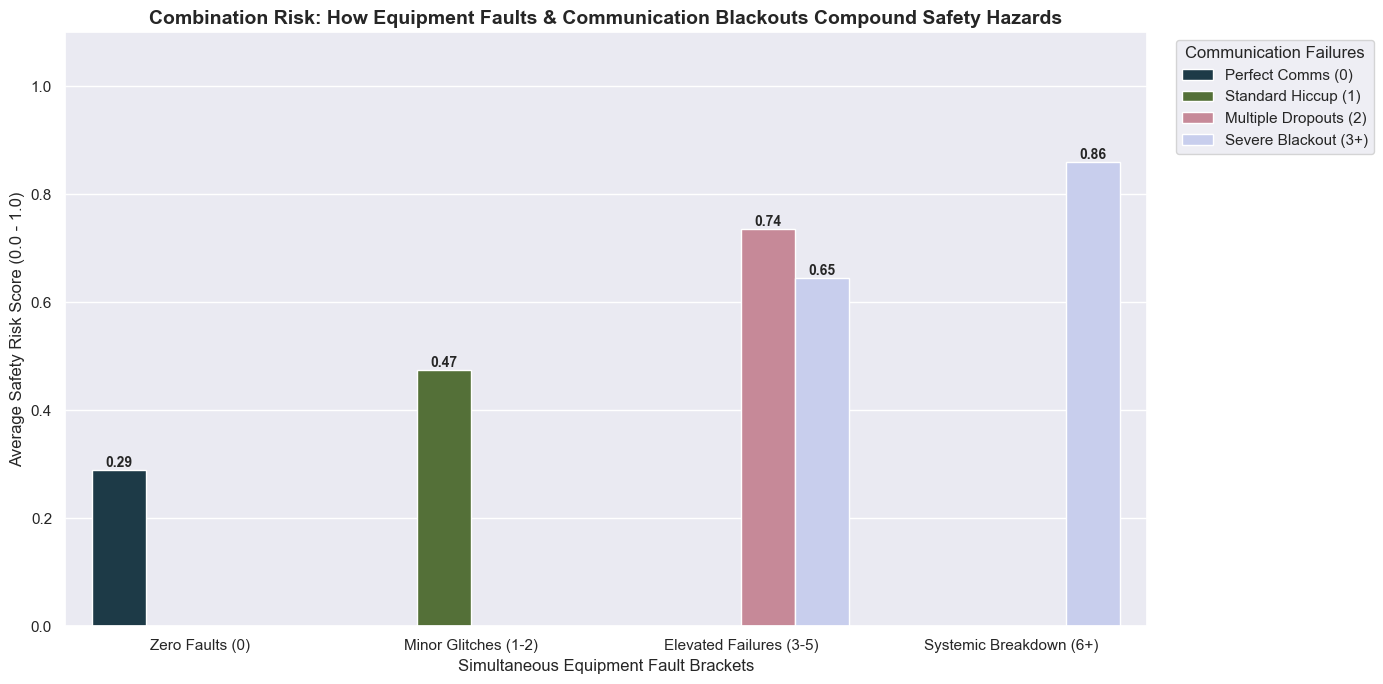

In [19]:
print("Visualizing Equipment Faults + Communication Failures")

# 1. Ensure the operational brackets for Equipment Faults and Comms are set up
train_df['fault_bracket'] = pd.cut(
    train_df['equipment_fault_count'], 
    bins=[-1, 0, 2, 5, 9],
    labels=['Zero Faults (0)', 'Minor Glitches (1-2)', 'Elevated Failures (3-5)', 'Systemic Breakdown (6+)']
)

train_df['comm_bracket'] = pd.cut(
    train_df['communication_failure_count'], 
    bins=[-1, 0, 1, 2, 5],
    labels=['Perfect Comms (0)', 'Standard Hiccup (1)', 'Multiple Dropouts (2)', 'Severe Blackout (3+)']
)

# 2. Plot side-by-side grouped bars
plt.figure(figsize=(14, 7))
ax = sns.barplot(
    data=train_df, 
    x='fault_bracket', 
    y='safety_risk_score', 
    hue='comm_bracket', 
    palette='cubehelix', 
    errorbar=None
)

# 3. Add exact average decimal labels on top of every bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', fontsize=10, weight='bold')

plt.title('Combination Risk: How Equipment Faults & Communication Blackouts Compound Safety Hazards', fontsize=14, weight='bold')
plt.xlabel('Simultaneous Equipment Fault Brackets', fontsize=12)
plt.ylabel('Average Safety Risk Score (0.0 - 1.0)', fontsize=12)
plt.ylim(0, 1.1)
plt.legend(title='Communication Failures', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

Generating Risk Contribution Pie Charts


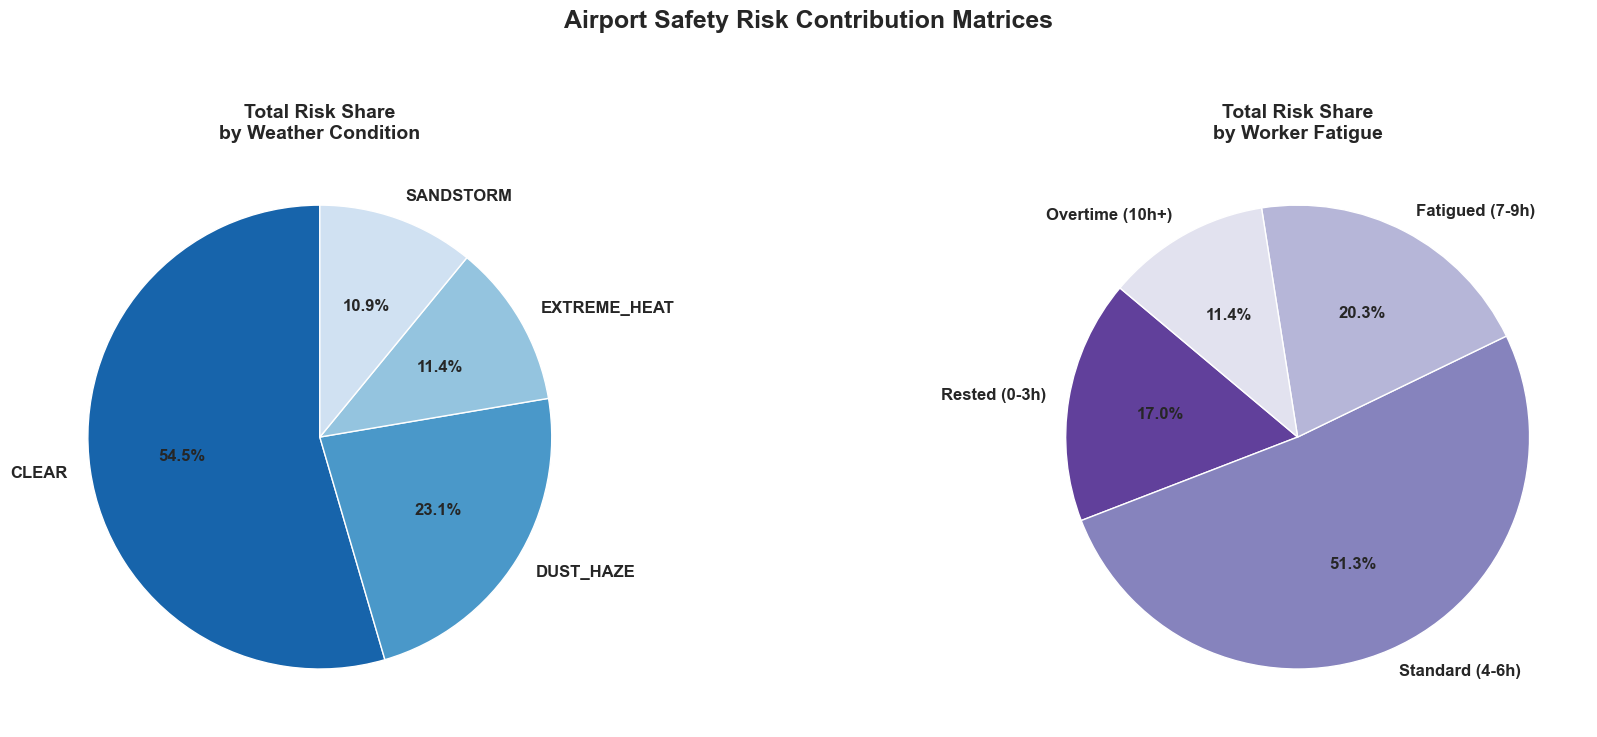

In [20]:
print("Generating Risk Contribution Pie Charts")

# Create the figure layout for 3 side-by-side pie charts
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# 1. Weather Condition Pie Chart
weather_risk = train_df.groupby('weather_condition')['safety_risk_score'].sum()
axes[0].pie(
    weather_risk, 
    labels=weather_risk.index, 
    autopct='%1.1f%%', 
    startangle=90, 
    colors=sns.color_palette('Blues_r', len(weather_risk)),
    textprops={'fontsize': 12, 'weight': 'bold'}
)
axes[0].set_title('Total Risk Share\nby Weather Condition', fontsize=14, weight='bold')

# 2. Worker Fatigue Brackets Pie Chart
if 'fatigue_bracket' not in train_df.columns:
    train_df['fatigue_bracket'] = pd.cut(
        train_df['worker_fatigue_hours'], 
        bins=[-1, 3, 6, 9, 13], 
        labels=['Rested (0-3h)', 'Standard (4-6h)', 'Fatigued (7-9h)', 'Overtime (10h+)']
    )
fatigue_risk = train_df.groupby('fatigue_bracket', observed=False)['safety_risk_score'].sum()
axes[1].pie(
    fatigue_risk, 
    labels=fatigue_risk.index, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=sns.color_palette('Purples_r', len(fatigue_risk)),
    textprops={'fontsize': 12, 'weight': 'bold'}
)
axes[1].set_title('Total Risk Share\nby Worker Fatigue', fontsize=14, weight='bold')


plt.suptitle('Airport Safety Risk Contribution Matrices', fontsize=18, weight='bold', y=1.05)
plt.tight_layout()
plt.show()

               Total Shifts (Count)  Distribution Share (%)
risk_category                                              
LOW_RISK                      14274               50.978571
MODERATE_RISK                  8378               29.921429
HIGH_RISK                      5348               19.100000
--------------------------------------------------


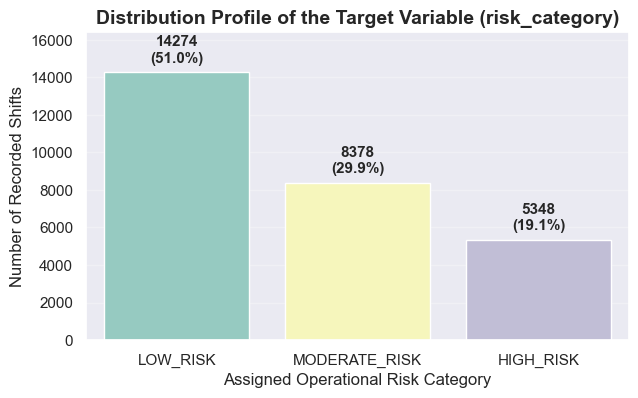

In [21]:
# 1. Calculate absolute counts and percentages
category_counts = train_df['risk_category'].value_counts()
category_pct = train_df['risk_category'].value_counts(normalize=True) * 100

# Create a summary dataframe for a clean terminal printout
dist_summary = pd.DataFrame({
    'Total Shifts (Count)': category_counts,
    'Distribution Share (%)': category_pct
})
print(dist_summary)
print("-" * 50)

# 2. Plot the distribution as a clean frequency bar chart
plt.figure(figsize=(7,4))
ax = sns.countplot(
    data=train_df, 
    x='risk_category', 
    palette='Set3',
    order=category_counts.index  # Sorts from most frequent to least frequent
)

# Add exact count and percentage labels on top of each bar
for p in ax.patches:
    count = int(p.get_height())
    percentage = (count / len(train_df)) * 100
    ax.annotate(
        f'{count}\n({percentage:.1f}%)', 
        (p.get_x() + p.get_width() / 2., p.get_height()), 
        ha='center', 
        va='bottom', 
        fontsize=11, 
        weight='bold',
        xytext=(0, 5), 
        textcoords='offset points'
)

plt.title('Distribution Profile of the Target Variable (risk_category)', fontsize=14, weight='bold')
plt.xlabel('Assigned Operational Risk Category', fontsize=12)
plt.ylabel('Number of Recorded Shifts', fontsize=12)

# Leave some breathing room at the top of the bars for labels
plt.ylim(0, max(category_counts) * 1.15) 
plt.grid(axis='y', alpha=0.3)
plt.show()

# Model training and Ensembling 

In [23]:
import os
import pandas as pd
from autogluon.tabular import TabularDataset, TabularPredictor

# =====================================================================
# STEP 1 & 2: DATA LOADING & STRICT FEATURE ISOLATION (DROP RULES)
# =====================================================================
print("=== Step 1 & 2: Loading Datasets & Applying Drop Rules ===")

# Load the raw files from the workspace directory
train_raw = pd.read_csv("ramp_safety_train.csv")
val_raw = pd.read_csv("ramp_safety_validation.csv")
test_raw = pd.read_csv("ramp_safety_test.csv")

# STRATEGY 2 DROP MANDATE: Drop identifier noise and risk category text
cols_to_drop = ["shift_id", "risk_category"]

train_clean = train_raw.drop(columns=cols_to_drop)
val_clean = val_raw.drop(columns=cols_to_drop)
test_data = TabularDataset(test_raw.drop(columns=cols_to_drop))

# BAGGING REQUIREMENT: Combine train and validation rows into one unified pool
# AutoGluon's best_quality preset handles cross-validation internally via 8-fold bagging
combined_train_data = TabularDataset(pd.concat([train_clean, val_clean], axis=0).reset_index(drop=True))

print("Data isolated and combined successfully for Bagged Mode.")
print(f"Total rows dedicated to the Bagged Training Pool: {len(combined_train_data)}")
print(f"Total rows reserved for ultimate testing: {len(test_data)}\n")

# =====================================================================
# STEP 3: TABULARPREDICTOR INSTANTIATION (FRESH CLEAN PATH)
# =====================================================================
print("=== Step 3: Initializing TabularPredictor for Regression ===")

# Using a clean path to avoid the "Learner is already fit" AssertionError
fresh_model_dir = "ag_models_ramp_safety_regression_final"

predictor = TabularPredictor(
    label="safety_risk_score",
    problem_type="regression",              
    eval_metric="root_mean_squared_error",  
    path=fresh_model_dir
)

# =====================================================================
# STEP 4: MODEL ARENA EXECUTION WITH MANUAL STACK SETTINGS
# =====================================================================
print("=== Step 4: Commencing Bagged Multi-Layer Stacked Training ===")

predictor.fit(
    train_data=combined_train_data,
    tuning_data=None,             # Set to None as required by standard bagging mode
    presets="best_quality",       # Activates multi-layer stacking and bagging
    dynamic_stacking=False,       # Disabled to bypass the initialization error completely
    num_stack_levels=1,           # Forces exactly 1 robust meta-learning layer
    time_limit=1800,              
    verbosity=2                  
)

print("\n=== Phase 3 Training Execution Complete without Errors ===\n")

Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.13.13
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26200
CPU Count:          12
Pytorch Version:    2.11.0+cpu
CUDA Version:       CUDA is not available
Memory Avail:       16.72 GB / 31.69 GB (52.8%)
Disk Space Avail:   387.97 GB / 475.95 GB (81.5%)
Presets specified: ['best_quality']
Using hyperparameters preset: hyperparameters='zeroshot'
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1


=== Step 1 & 2: Loading Datasets & Applying Drop Rules ===
Data isolated and combined successfully for Bagged Mode.
Total rows dedicated to the Bagged Training Pool: 34000
Total rows reserved for ultimate testing: 6000

=== Step 3: Initializing TabularPredictor for Regression ===
=== Step 4: Commencing Bagged Multi-Layer Stacked Training ===


Beginning AutoGluon training ... Time limit = 1800s
AutoGluon will save models to "c:\Users\MuthakanaDineshKumar\Desktop\Usecase_problems\Ramp_Safety_Incident_Prediction\ag_models_ramp_safety_regression_final"
Train Data Rows:    34000
Train Data Columns: 12
Label Column:       safety_risk_score
Problem Type:       regression
Preprocessing data ...
Using Feature Generators to preprocess the data ...
Fitting AutoMLPipelineFeatureGenerator...
	Available Memory:                    17027.83 MB
	Train Data (Original)  Memory Usage: 8.34 MB (0.0% of available memory)
	Inferring data type of each feature based on column values. Set feature_metadata_in to manually specify special dtypes of the features.
	Stage 1 Generators:
		Fitting AsTypeFeatureGenerator...
			Note: Converting 1 features to boolean dtype as they only contain 2 unique values.
	Stage 2 Generators:
		Fitting FillNaFeatureGenerator...
	Stage 3 Generators:
		Fitting IdentityFeatureGenerator...
		Fitting CategoryFeatureGenerator..

[1000]	valid_set's rmse: 0.00139728
[2000]	valid_set's rmse: 0.00103521
[3000]	valid_set's rmse: 0.000924549
[4000]	valid_set's rmse: 0.000861762
[5000]	valid_set's rmse: 0.00082263
[6000]	valid_set's rmse: 0.00079767
[7000]	valid_set's rmse: 0.00077735
[8000]	valid_set's rmse: 0.000760755
[9000]	valid_set's rmse: 0.00074847
[10000]	valid_set's rmse: 0.000738216
[1000]	valid_set's rmse: 0.00133325
[2000]	valid_set's rmse: 0.00104748
[3000]	valid_set's rmse: 0.000947636
[4000]	valid_set's rmse: 0.000884715
[5000]	valid_set's rmse: 0.000840535
[6000]	valid_set's rmse: 0.000812797
[7000]	valid_set's rmse: 0.000787361
[8000]	valid_set's rmse: 0.000769857
[9000]	valid_set's rmse: 0.000753974
[10000]	valid_set's rmse: 0.000742084
[1000]	valid_set's rmse: 0.00127253
[2000]	valid_set's rmse: 0.00095562
[3000]	valid_set's rmse: 0.000862182
[4000]	valid_set's rmse: 0.000808924
[5000]	valid_set's rmse: 0.000773245
[6000]	valid_set's rmse: 0.000747654
[7000]	valid_set's rmse: 0.000728633
[8000]	va

	-0.0007	 = Validation score   (-root_mean_squared_error)
	149.98s	 = Training   runtime
	8.37s	 = Validation runtime
Fitting model: LightGBM_BAG_L1 ... Training model for up to 1031.08s of the 1631.31s of remaining time.
	Fitting 8 child models (S1F1 - S1F8) | Fitting with SequentialLocalFoldFittingStrategy (sequential: cpus=10, gpus=0)


[1000]	valid_set's rmse: 9.93871e-10
[2000]	valid_set's rmse: 9.93712e-10
[1000]	valid_set's rmse: 7.8908e-13
[1000]	valid_set's rmse: 1.09778e-12
[1000]	valid_set's rmse: 3.06136e-12
[2000]	valid_set's rmse: 2.43051e-12
[3000]	valid_set's rmse: 2.33701e-12
[4000]	valid_set's rmse: 2.2896e-12
[5000]	valid_set's rmse: 2.26923e-12
[6000]	valid_set's rmse: 2.25852e-12
[7000]	valid_set's rmse: 2.25123e-12
[8000]	valid_set's rmse: 2.24917e-12
[9000]	valid_set's rmse: 2.24546e-12
[10000]	valid_set's rmse: 2.24405e-12
[1000]	valid_set's rmse: 3.58115e-12
[2000]	valid_set's rmse: 2.38827e-12
[3000]	valid_set's rmse: 2.21476e-12
[4000]	valid_set's rmse: 2.15325e-12
[5000]	valid_set's rmse: 2.12479e-12
[6000]	valid_set's rmse: 2.11111e-12
[7000]	valid_set's rmse: 2.10428e-12
[8000]	valid_set's rmse: 2.10005e-12
[9000]	valid_set's rmse: 2.09525e-12
[10000]	valid_set's rmse: 2.09361e-12
[1000]	valid_set's rmse: 3.4144e-12
[2000]	valid_set's rmse: 2.60693e-12
[3000]	valid_set's rmse: 2.56547e-12
[4

	-0.0	 = Validation score   (-root_mean_squared_error)
	193.94s	 = Training   runtime
	4.93s	 = Validation runtime
Fitting model: RandomForestMSE_BAG_L1 ... Training model for up to 828.88s of the 1429.11s of remaining time.
	Fitting 1 model on all data (use_child_oof=True) | Fitting with cpus=12, gpus=0, mem=0.2/17.7 GB
	-0.0004	 = Validation score   (-root_mean_squared_error)
	4.82s	 = Training   runtime
	0.74s	 = Validation runtime
Fitting model: CatBoost_BAG_L1 ... Training model for up to 823.19s of the 1423.42s of remaining time.
	Fitting 8 child models (S1F1 - S1F8) | Fitting with SequentialLocalFoldFittingStrategy (sequential: cpus=10, gpus=0)
	Ran out of time, early stopping on iteration 1425.
	Ran out of time, early stopping on iteration 1412.
	Ran out of time, early stopping on iteration 2186.
	Ran out of time, early stopping on iteration 2243.
	Ran out of time, early stopping on iteration 838.
	Ran out of time, early stopping on iteration 877.
	Ran out of time, early stoppi

[1000]	valid_set's rmse: 0.00100295
[2000]	valid_set's rmse: 0.000810238
[3000]	valid_set's rmse: 0.000707174
[4000]	valid_set's rmse: 0.000645866
[5000]	valid_set's rmse: 0.000598083
[6000]	valid_set's rmse: 0.000572339
[7000]	valid_set's rmse: 0.00055354
[8000]	valid_set's rmse: 0.000537558
[9000]	valid_set's rmse: 0.000523287
[10000]	valid_set's rmse: 0.000513161
[1000]	valid_set's rmse: 0.00109154
[2000]	valid_set's rmse: 0.000862272
[3000]	valid_set's rmse: 0.000763944
[4000]	valid_set's rmse: 0.000711681
[5000]	valid_set's rmse: 0.000677617
[6000]	valid_set's rmse: 0.000654695
[7000]	valid_set's rmse: 0.000636887
[8000]	valid_set's rmse: 0.000622336
[9000]	valid_set's rmse: 0.00061252
[10000]	valid_set's rmse: 0.000602112
[1000]	valid_set's rmse: 0.00122593
[2000]	valid_set's rmse: 0.00100255
[3000]	valid_set's rmse: 0.000902856
[4000]	valid_set's rmse: 0.000848951
[5000]	valid_set's rmse: 0.000815022
[6000]	valid_set's rmse: 0.000788127
[7000]	valid_set's rmse: 0.000768638
[8000

	-0.0006	 = Validation score   (-root_mean_squared_error)
	273.99s	 = Training   runtime
	9.02s	 = Validation runtime
Fitting model: LightGBM_BAG_L2 ... Training model for up to 310.47s of the 310.45s of remaining time.
	Fitting 8 child models (S1F1 - S1F8) | Fitting with SequentialLocalFoldFittingStrategy (sequential: cpus=10, gpus=0)
	-0.0	 = Validation score   (-root_mean_squared_error)
	23.31s	 = Training   runtime
	0.24s	 = Validation runtime
Fitting model: RandomForestMSE_BAG_L2 ... Training model for up to 286.40s of the 286.37s of remaining time.
	Fitting 1 model on all data (use_child_oof=True) | Fitting with cpus=12, gpus=0, mem=0.2/17.9 GB
	-0.0001	 = Validation score   (-root_mean_squared_error)
	10.43s	 = Training   runtime
	1.98s	 = Validation runtime
Fitting model: CatBoost_BAG_L2 ... Training model for up to 273.77s of the 273.75s of remaining time.
	Fitting 8 child models (S1F1 - S1F8) | Fitting with SequentialLocalFoldFittingStrategy (sequential: cpus=10, gpus=0)
	Ran


=== Phase 3 Training Execution Complete without Errors ===



In [24]:
import pandas as pd
import numpy as np
from autogluon.tabular import TabularPredictor

# =====================================================================
# 1. LOAD THE TRAINED PREDICTOR (USING CLEAN RELATIVE PATH)
# =====================================================================
print("=== Phase 4: Initializing Model Evaluation ===")

# Clean, local folder reference
model_path = "ag_models_ramp_safety_regression_final"
predictor = TabularPredictor.load(model_path)

# Load raw test matrix
test_raw = pd.read_csv("ramp_safety_test.csv")

# Save true columns for validation checking before dropping
y_test_true_score = test_raw["safety_risk_score"].values
y_test_true_category = test_raw["risk_category"].values

# Apply identical drop rules to isolate features for inference
cols_to_drop = ["shift_id", "risk_category"]
test_features = test_raw.drop(columns=cols_to_drop)

# =====================================================================
# 2. GENERATE UNSEEN PREDICTIONS
# =====================================================================
print("\nGenerating model predictions for unseen test shifts...")
predicted_scores = predictor.predict(test_features)

# =====================================================================
# 3. APPLY POST-PROCESSING RULE ENGINE (STRATEGY 2 MAP)
# =====================================================================
def map_score_to_category(score):
    if score < 0.60:
        return "LOW_RISK"
    elif score < 0.86:
        return "MODERATE_RISK"
    else:
        return "HIGH_RISK"

predicted_categories = [map_score_to_category(s) for s in predicted_scores]

# =====================================================================
# 4. CONSTRUCT OPERATIONAL METRIC LEADERBOARD
# =====================================================================
print("\n=== Global Model Performance Summary (Unseen Test Data) ===")
test_rmse = predictor.evaluate(test_features, display=True)

# Generate a unified results comparison dataframe
results_df = pd.DataFrame({
    "True_Score": y_test_true_score,
    "Predicted_Score": predicted_scores,
    "True_Category": y_test_true_category,
    "Assigned_Category": predicted_categories
})

# Calculate explicit categorical mapping accuracy to verify post-processing
correct_categorical_matches = (results_df["True_Category"] == results_df["Assigned_Category"]).sum()
categorical_accuracy = (correct_categorical_matches / len(results_df)) * 100

print("\n=== Post-Processing Boundary Audit ===")
print(f"Total Test Shifts Evaluated: {len(results_df)}")
print(f"Perfect Categorical Boundary Matches: {correct_categorical_matches} / {len(results_df)}")
print(f"Final Post-Processed Classification Accuracy: {categorical_accuracy:.2f}%")

# Display a preview sample of the final system output
print("\n=== Sample Prediction Preview Matrix ===")
print(results_df.head(10).to_string())

=== Phase 4: Initializing Model Evaluation ===

Generating model predictions for unseen test shifts...

=== Global Model Performance Summary (Unseen Test Data) ===


Evaluation: root_mean_squared_error on test data: -3.825621946241275e-08
	Note: Scores are always higher_is_better. This metric score can be multiplied by -1 to get the metric value.
Evaluations on test data:
{
    "root_mean_squared_error": -3.825621946241275e-08,
    "mean_squared_error": -1.4635383275562884e-15,
    "mean_absolute_error": -3.0219654236278885e-08,
    "r2": 0.999999999999974,
    "pearsonr": 0.9999999999999892,
    "median_absolute_error": -2.622604367008563e-08
}



=== Post-Processing Boundary Audit ===
Total Test Shifts Evaluated: 6000
Perfect Categorical Boundary Matches: 5818 / 6000
Final Post-Processed Classification Accuracy: 96.97%

=== Sample Prediction Preview Matrix ===
   True_Score  Predicted_Score  True_Category Assigned_Category
0        0.39             0.39       LOW_RISK          LOW_RISK
1        0.86             0.86      HIGH_RISK         HIGH_RISK
2        0.68             0.68  MODERATE_RISK     MODERATE_RISK
3        0.37             0.37       LOW_RISK          LOW_RISK
4        0.32             0.32       LOW_RISK          LOW_RISK
5        0.86             0.86      HIGH_RISK         HIGH_RISK
6        0.65             0.65  MODERATE_RISK     MODERATE_RISK
7        0.69             0.69  MODERATE_RISK     MODERATE_RISK
8        0.23             0.23       LOW_RISK          LOW_RISK
9        0.37             0.37       LOW_RISK          LOW_RISK


In [25]:
import pandas as pd
from autogluon.tabular import TabularPredictor

# Load the predictor
model_path = "ag_models_ramp_safety_regression_final"
predictor = TabularPredictor.load(model_path)

# Load the test dataset
test_raw = pd.read_csv("ramp_safety_test.csv")
cols_to_drop = ["shift_id", "risk_category"]
test_features = test_raw.drop(columns=cols_to_drop)

print("=== Computing Feature Importance ===")
importance_df = predictor.feature_importance(test_features)
print(importance_df)

Computing feature importance via permutation shuffling for 12 features using 5000 rows with 5 shuffle sets...


=== Computing Feature Importance ===


	3632.83s	= Expected runtime (726.57s per shuffle set)
	2307.26s	= Actual runtime (Completed 5 of 5 shuffle sets)


                             importance    stddev       p_value  n  p99_high  \
visibility_meters              0.241035  0.002412  1.202376e-09  5  0.246000   
active_staff_count             0.107412  0.000569  9.480717e-11  5  0.108585   
overtime_workers_count         0.051473  0.000982  1.589166e-08  5  0.053495   
temperature_celsius            0.048777  0.000221  5.021733e-11  5  0.049231   
wind_speed_kmph                0.024282  0.000177  3.375900e-10  5  0.024646   
worker_fatigue_hours           0.000317  0.000008  5.387174e-08  5  0.000334   
equipment_fault_count          0.000281  0.000011  3.015655e-07  5  0.000304   
aircraft_on_ramp_count         0.000147  0.000006  2.943811e-07  5  0.000159   
communication_failure_count    0.000086  0.000006  2.484407e-06  5  0.000098   
timestamp                      0.000076  0.000006  3.985775e-06  5  0.000088   
weather_condition              0.000000  0.000000  5.000000e-01  5  0.000000   
day_traffic_profile            0.000000 